In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\DS Learning\DAtasets/housing.csv")
df["income_cat"] = pd.cut(df["median_income"],
                             bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                             labels=[1, 2, 3, 4, 5])

# shuffle_and_split(df, 0.2)
# df.head()
# df["median_income"].value_counts()


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  object  
 10  income_cat          20640 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.6+ MB


### To ensure that important characteristics of the population are well represented in both the training and test sets, we use stratified sampling.

### **What is a Strata?**

A strata is a subgroup of the df defined by a specific attribute. Stratified sampling ensures that each of these subgroups is proportionally represented.

For example, in the California housing dfset, median income is a strong predictor of house prices. Instead of randomly sampling, we can create strata based on income levels (e.g., binning median income into categories) and ensure the test set maintains the same distribution of income levels as the full dfset.

In [5]:
# Scikit-learn provides a built-in way to perform stratified sampling using StratifiedShuffleSplit.

from sklearn.model_selection import StratifiedShuffleSplit

# Assume income_cat is a column in the dfset created from median_income
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

Now lets remove the income_cat column

In [6]:
for sett in (strat_train_set, strat_test_set):
    sett.drop("income_cat", axis=1, inplace=True)

Now lets make a copy of our Training set

In [9]:
data = strat_train_set.copy()

### visualizing the house prices on which area the prices are high by plotting a *California* map

<Axes: xlabel='latitude', ylabel='longitude'>

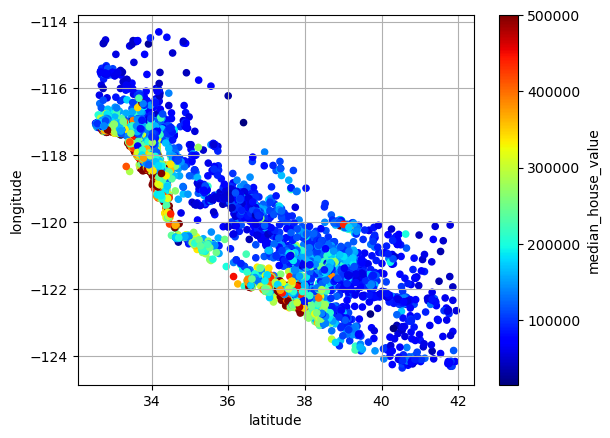

In [20]:
data.plot(x="latitude", y="longitude", grid=True, kind="scatter", cmap="jet", c="median_house_value")

In [32]:
data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


### Now we find correltion between the variables

<Axes: >

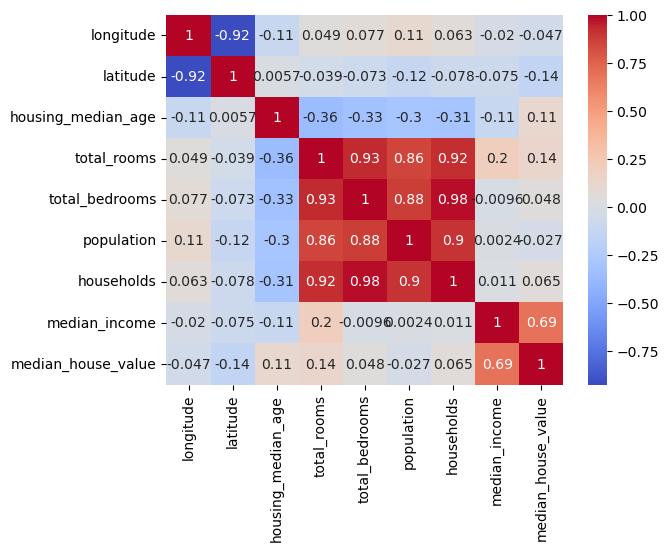

In [25]:
data.drop("ocean_proximity", axis=1, inplace=True)
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

### Now we find correlation by ploting scatter matrix

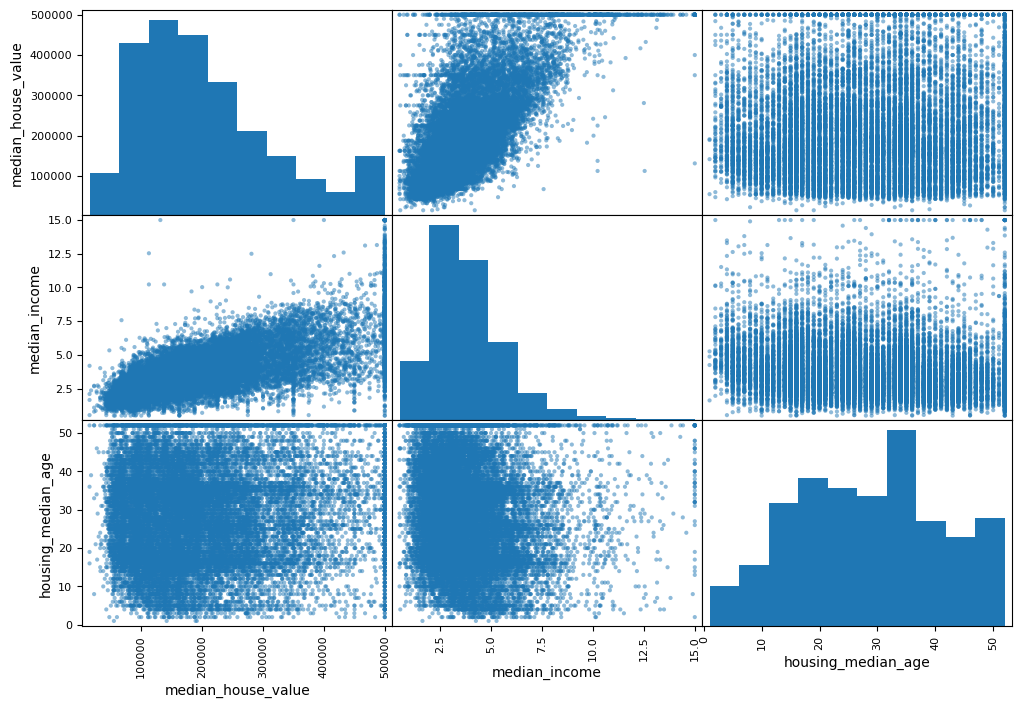

In [30]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()